In [ ]:
import sys, os, argparse
sys.path.append(os.path.abspath(".."))

import numpy as np
import torch
import torch.multiprocessing as mp
from tqdm import tqdm
import itertools
import re
import matplotlib.pyplot as plt

import grid_pkg
import controller_pkg
import controller_utils
import dQPTH
import evals

torch.set_default_dtype(torch.double)
torch.set_printoptions(threshold=10000)
NUMPY_SEED = 0
forecast_seed = 0
np.random.seed(NUMPY_SEED)
torch.manual_seed(forecast_seed)

skipping pardiso


In [2]:
line_data_loc = '../data/case118_line_data.pt'
bus_data_loc = '../data/case118_bus_data.pt'
gen_data_loc = '../data/case118_gen_data.pt'
ptdf_data_loc = '../data/case118_ptdf_data.pt'

bus_with_curt = torch.load(gen_data_loc, weights_only=True)[:,0].int()
num_curt = bus_with_curt.shape[0]
bus_with_batt = torch.tensor([10*i+2 for i in range(12)], dtype=torch.int)
num_batt = bus_with_batt.shape[0]
delta_t = 15

grid = grid_pkg.Grid(bus_with_curt, bus_with_batt, delta_t, line_data_loc, bus_data_loc, gen_data_loc, ptdf_data_loc)
num_agents = 3
nodes_1 = [i for i in range(0, 42)] + [112, 113, 114, 116]
nodes_2 = [i for i in range(42, 69)] + [115]
nodes_3 = [i for i in range(69, 112)] + [117]
partition = [nodes_1, nodes_2, nodes_3]
batt_cost = 100
curt_change_cost = 0.01
curt_net_cost = 1
bus_slack_cost = 1e8
line_slack_cost = 1e2
initial_state = grid.state

noise_mag = 4.0
bus_idx_gap = 10
T = 20
H = 5
file_path = "../data/tauxDeChargeMTJLMA2juillet2018.txt"
train_skew = controller_utils.get_RTE_noise_values(file_path, grid, T, H, noise_mag, bus_idx_gap)

controller_list = controller_utils.create_split_constraint_controllers(grid, num_agents, partition, T, H, batt_cost, curt_change_cost,
                                                                 curt_net_cost, bus_slack_cost, line_slack_cost)
controller_1, controller_2, controller_3 = controller_list
pool = mp.Pool(processes=num_agents)
settings = dQPTH.build_settings(solve_type="sparse", qp_solver="gurobi", lin_solver="qdldl", warm_start_from_previous=True)
dQPTH_layer = dQPTH.dQPTH_layer(settings=settings, pool=pool)

/Users/jameschen/Documents/RTE/ACM 26 Camera Ready/controller_pkg.py:755: UserWarning: Sparse CSC tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:55.)
  self.csc_scaled_Q = self.scaled_Q.to_sparse_csc()


## hard case

In [ ]:
our_losses_dict = dict()
surrogate_losses_dict = dict()

noise_mag = 4.0
offset = 180
test_skew_mag = 40
test_seed = 2
forecast_seed = 0
epochs = 120
lr = 1e-3
radius = 0.2
optimizer_type = "clipped_gd"
lr_schedule = "plateau"
patience = 5
batch_size = 2
max_grad_norm = 3e4
default_lr_decay = 20

FOLDER_PATH = "ours"
filename = f"ours_noise_mag{noise_mag}_offset{offset}_epochs{epochs}_lr{lr}_forecast_seed{forecast_seed}_radius{radius}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}.pt"

ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
test_trajs_with_mismatch = torch.load(f'../data/scenario_generation/test_trajs_with_mismatch_rad{radius}/test_trajs_with_mismatch_noise_mag{noise_mag}_offset{offset}_tsm{test_skew_mag}.pt')
num_test_traj = test_trajs_with_mismatch["num_test_traj"]
all_test_trajs = test_trajs_with_mismatch[(noise_mag, offset, test_skew_mag, test_seed)]
test_traj = all_test_trajs[0]

line_max_changes = ckpt["line_max_changes"]
line_min_changes = ckpt["line_min_changes"]
controller_utils.assign_line_limit_changes(controller_list, line_max_changes, line_min_changes)

In [21]:
total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)

grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    pred_actions_curt, pred_actions_batt, pred_line_max_slacks, pred_line_min_slacks, pred_bus_slacks = \
        controller_utils.get_next_action(grid, controller_list, noise, t, dQPTH_layer, verbose=False, update_state=True)

    action_curt = pred_actions_curt[0]
    action_batt = pred_actions_batt[0]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_ours = impacts.detach()
true_line_flow_ours = true_line_flow.detach()

skipping pardisoskipping pardiso

skipping pardiso
Set parameter Username
Set parameter Username
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06


In [22]:
ckpt_central = evals.get_central_full_traj(grid, T, H, test_traj, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)
total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)
actions_batt_opt = ckpt_central["actions_batt"]
actions_curt_opt = ckpt_central["actions_curt"]
grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    action_curt = actions_curt_opt[t]
    action_batt = actions_batt_opt[t]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_opt = impacts.detach()
true_line_flow_opt = true_line_flow.detach()

skipping pardiso
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-06


In [24]:
base_controller_list = controller_utils.create_base_controllers(grid, num_agents, partition, T, H, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)
for controller in base_controller_list:
    controller.init_matrices()
    
pool = mp.Pool(processes=num_agents)
dqp_eps = 1
settings = dQPTH.build_settings(solve_type="sparse", qp_solver="gurobi", lin_solver="qdldl", warm_start_from_previous=True)
base_dQPTH_layer = dQPTH.dQPTH_layer(settings=settings, pool=pool)
ckpt_base = evals.evaluate_base_on_traj(grid, base_controller_list, base_dQPTH_layer, test_traj, T, H, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)

total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)
actions_batt_base = ckpt_base["actions_batt"]
actions_curt_base = ckpt_base["actions_curt"]
grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    action_curt = actions_curt_base[t]
    action_batt = actions_batt_base[t]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_base = impacts.detach()
true_line_flow_base = true_line_flow.detach()

skipping pardiso
skipping pardiso
skipping pardiso
Set parameter Username
Set parameter Username
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06


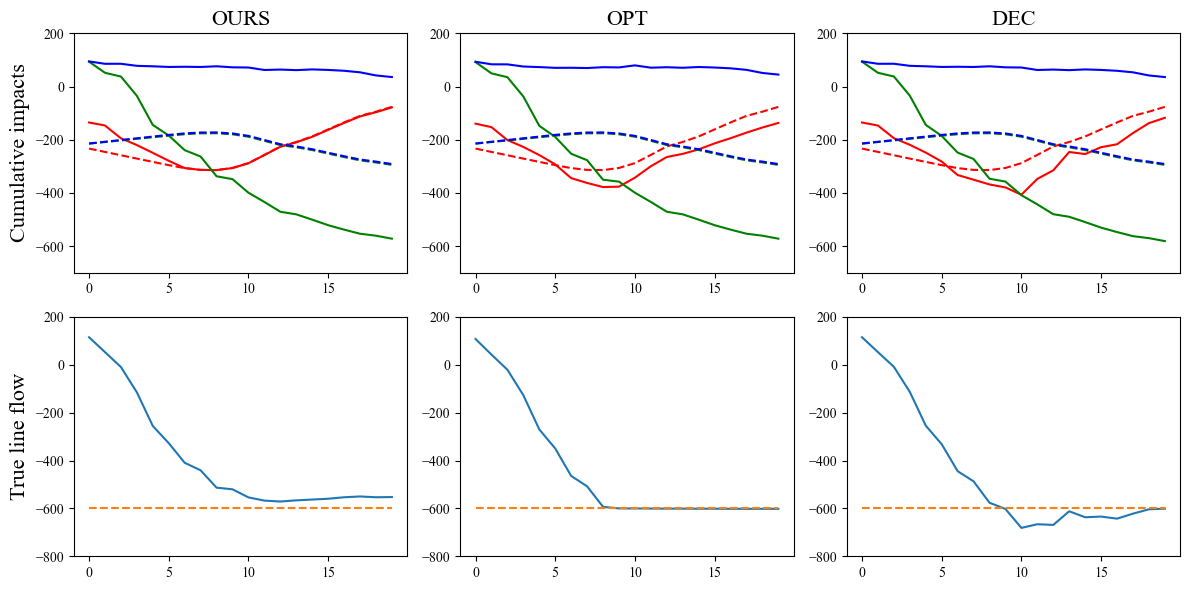

In [28]:
colors = {0: "red", 1: "green", 2: "blue"}
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
fig, axs = plt.subplots(2,3,figsize=(12,6))
colors = {0: "red", 1: "green", 2: "blue"}

for i in range(3):
    # axs[0,0].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,0].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,0].plot(impacts_ours[i], color=colors[i])
axs[0,0].set_title("OURS",fontsize=16)
axs[0,0].set_ylabel("Cumulative impacts",fontsize=16)
axs[0,0].set_ylim([-700,200])
axs[1,0].plot(true_line_flow_ours)
axs[1,0].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,0].set_ylabel("True line flow",fontsize=16)
axs[1,0].set_ylim([-800,200])

for i in range(3):
    # axs[0,1].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,1].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,1].plot(impacts_opt[i], color=colors[i])
axs[0,1].set_title("OPT",fontsize=16)
axs[0,1].set_ylim([-700,200])
axs[1,1].plot(true_line_flow_opt)
axs[1,1].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,1].set_ylim([-800,200])

for i in range(3):
    # axs[0,2].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,2].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,2].plot(impacts_base[i], color=colors[i])
axs[0,2].set_title("DEC",fontsize=16)
axs[0,2].set_ylim([-700,200])
axs[1,2].plot(true_line_flow_base)
axs[1,2].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,2].set_ylim([-800,200])

fig.tight_layout()
fig.savefig("figures/hard case.png", dpi=500, bbox_inches='tight')

## medium case

In [ ]:
our_losses_dict = dict()
surrogate_losses_dict = dict()

noise_mag = 3.0
offset = 60
test_skew_mag = 30
test_seed = 0
forecast_seed = 0
epochs = 120
lr = 1e-3
radius = 0.2
optimizer_type = "clipped_gd"
lr_schedule = "plateau"
patience = 5
batch_size = 2
max_grad_norm = 3e4
default_lr_decay = 20

FOLDER_PATH = "ours"
filename = f"ours_noise_mag{noise_mag}_offset{offset}_epochs{epochs}_lr{lr}_forecast_seed{forecast_seed}_radius{radius}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}.pt"

ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
test_trajs_with_mismatch = torch.load(f'../data/scenario_generation/test_trajs_with_mismatch_rad{radius}/test_trajs_with_mismatch_noise_mag{noise_mag}_offset{offset}_tsm{test_skew_mag}.pt')
num_test_traj = test_trajs_with_mismatch["num_test_traj"]
all_test_trajs = test_trajs_with_mismatch[(noise_mag, offset, test_skew_mag, test_seed)]
test_traj = all_test_trajs[0]

line_max_changes = ckpt["line_max_changes"]
line_min_changes = ckpt["line_min_changes"]
controller_utils.assign_line_limit_changes(controller_list, line_max_changes, line_min_changes)

In [4]:
total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)

grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    pred_actions_curt, pred_actions_batt, pred_line_max_slacks, pred_line_min_slacks, pred_bus_slacks = \
        controller_utils.get_next_action(grid, controller_list, noise, t, dQPTH_layer, verbose=False, update_state=True)

    action_curt = pred_actions_curt[0]
    action_batt = pred_actions_batt[0]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_ours = impacts.detach()
true_line_flow_ours = true_line_flow.detach()

skipping pardiso
skipping pardiso
skipping pardiso
Set parameter Username
Set parameter Username
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06


In [5]:
ckpt_central = evals.get_central_full_traj(grid, T, H, test_traj, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)
total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)
actions_batt_opt = ckpt_central["actions_batt"]
actions_curt_opt = ckpt_central["actions_curt"]
grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    action_curt = actions_curt_opt[t]
    action_batt = actions_batt_opt[t]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_opt = impacts.detach()
true_line_flow_opt = true_line_flow.detach()

skipping pardiso
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-06


In [6]:
base_controller_list = controller_utils.create_base_controllers(grid, num_agents, partition, T, H, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)
for controller in base_controller_list:
    controller.init_matrices()
    
pool = mp.Pool(processes=num_agents)
dqp_eps = 1
settings = dQPTH.build_settings(solve_type="sparse", qp_solver="gurobi", lin_solver="qdldl", warm_start_from_previous=True)
base_dQPTH_layer = dQPTH.dQPTH_layer(settings=settings, pool=pool)
ckpt_base = evals.evaluate_base_on_traj(grid, base_controller_list, base_dQPTH_layer, test_traj, T, H, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)

total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)
actions_batt_base = ckpt_base["actions_batt"]
actions_curt_base = ckpt_base["actions_curt"]
grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    action_curt = actions_curt_base[t]
    action_batt = actions_batt_base[t]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_base = impacts.detach()
true_line_flow_base = true_line_flow.detach()

skipping pardisoskipping pardiso

skipping pardiso
Set parameter Username
Set parameter Username
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06


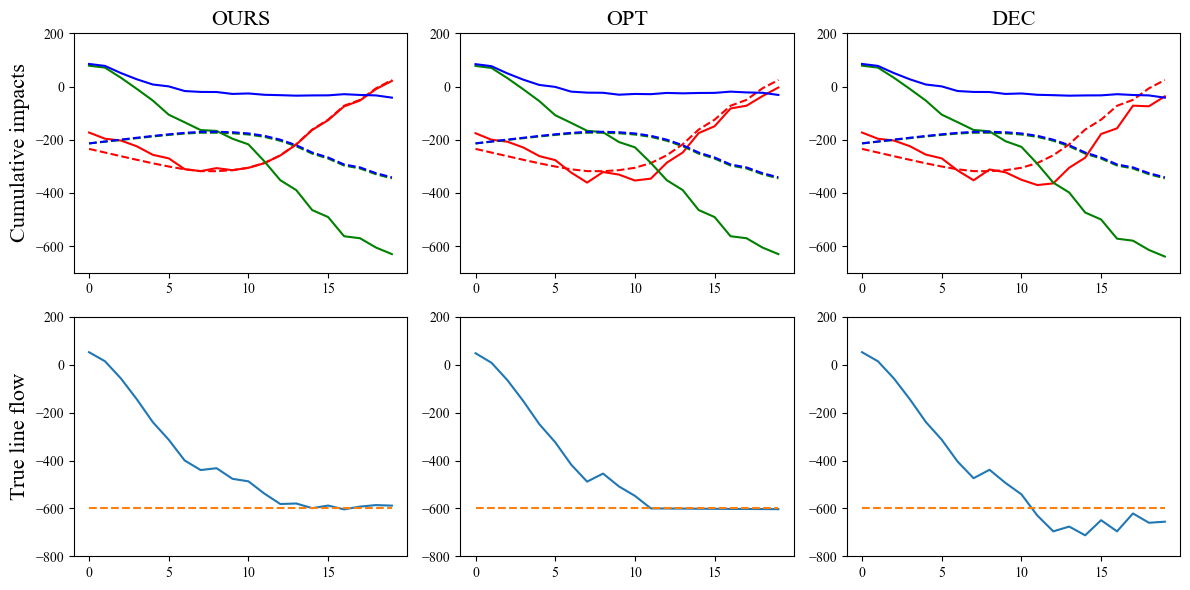

In [7]:
colors = {0: "red", 1: "green", 2: "blue"}
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
fig, axs = plt.subplots(2,3,figsize=(12,6))
colors = {0: "red", 1: "green", 2: "blue"}

for i in range(3):
    # axs[0,0].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,0].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,0].plot(impacts_ours[i], color=colors[i])
axs[0,0].set_title("OURS",fontsize=16)
axs[0,0].set_ylabel("Cumulative impacts",fontsize=16)
axs[0,0].set_ylim([-700,200])
axs[1,0].plot(true_line_flow_ours)
axs[1,0].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,0].set_ylabel("True line flow",fontsize=16)
axs[1,0].set_ylim([-800,200])

for i in range(3):
    # axs[0,1].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,1].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,1].plot(impacts_opt[i], color=colors[i])
axs[0,1].set_title("OPT",fontsize=16)
axs[0,1].set_ylim([-700,200])
axs[1,1].plot(true_line_flow_opt)
axs[1,1].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,1].set_ylim([-800,200])

for i in range(3):
    # axs[0,2].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,2].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,2].plot(impacts_base[i], color=colors[i])
axs[0,2].set_title("DEC",fontsize=16)
axs[0,2].set_ylim([-700,200])
axs[1,2].plot(true_line_flow_base)
axs[1,2].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,2].set_ylim([-800,200])

fig.tight_layout()
fig.savefig("figures/medium case.png", dpi=500, bbox_inches='tight')

## easy case

In [ ]:
our_losses_dict = dict()
surrogate_losses_dict = dict()

noise_mag = 2.4
offset = 0
test_skew_mag = 10
test_seed = 2
forecast_seed = 0
epochs = 120
lr = 1e-3
radius = 0.2
optimizer_type = "clipped_gd"
lr_schedule = "plateau"
patience = 5
batch_size = 2
max_grad_norm = 3e4
default_lr_decay = 20

FOLDER_PATH = "ours"
filename = f"ours_noise_mag{noise_mag}_offset{offset}_epochs{epochs}_lr{lr}_forecast_seed{forecast_seed}_radius{radius}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}.pt"

ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
test_trajs_with_mismatch = torch.load(f'../data/scenario_generation/test_trajs_with_mismatch_rad{radius}/test_trajs_with_mismatch_noise_mag{noise_mag}_offset{offset}_tsm{test_skew_mag}.pt')
num_test_traj = test_trajs_with_mismatch["num_test_traj"]
all_test_trajs = test_trajs_with_mismatch[(noise_mag, offset, test_skew_mag, test_seed)]
test_traj = all_test_trajs[0]

line_max_changes = ckpt["line_max_changes"]
line_min_changes = ckpt["line_min_changes"]
controller_utils.assign_line_limit_changes(controller_list, line_max_changes, line_min_changes)

In [37]:
total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)

grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    pred_actions_curt, pred_actions_batt, pred_line_max_slacks, pred_line_min_slacks, pred_bus_slacks = \
        controller_utils.get_next_action(grid, controller_list, noise, t, dQPTH_layer, verbose=False, update_state=True)

    action_curt = pred_actions_curt[0]
    action_batt = pred_actions_batt[0]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_ours = impacts.detach()
true_line_flow_ours = true_line_flow.detach()

In [38]:
ckpt_central = evals.get_central_full_traj(grid, T, H, test_traj, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)
total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)
actions_batt_opt = ckpt_central["actions_batt"]
actions_curt_opt = ckpt_central["actions_curt"]
grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    action_curt = actions_curt_opt[t]
    action_batt = actions_batt_opt[t]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_opt = impacts.detach()
true_line_flow_opt = true_line_flow.detach()

skipping pardiso
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-06


In [39]:
base_controller_list = controller_utils.create_base_controllers(grid, num_agents, partition, T, H, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)
for controller in base_controller_list:
    controller.init_matrices()
    
pool = mp.Pool(processes=num_agents)
dqp_eps = 1
settings = dQPTH.build_settings(solve_type="sparse", qp_solver="gurobi", lin_solver="qdldl", warm_start_from_previous=True)
base_dQPTH_layer = dQPTH.dQPTH_layer(settings=settings, pool=pool)
ckpt_base = evals.evaluate_base_on_traj(grid, base_controller_list, base_dQPTH_layer, test_traj, T, H, batt_cost, curt_change_cost, curt_net_cost, bus_slack_cost, line_slack_cost)

total_loss = 0
total_econ_loss = 0
total_viol_loss = 0
total_train_loss = 0

line = 53
true_line_flow = torch.zeros(T)
impacts = torch.zeros(num_agents, T)
actions_batt_base = ckpt_base["actions_batt"]
actions_curt_base = ckpt_base["actions_curt"]
grid.reset_state()
for controller in controller_list:
    controller.zero_line_state()
    controller.update_bus_state()
for t in range(T):
    noise = test_traj[t:t+H,:]
    action_curt = actions_curt_base[t]
    action_batt = actions_batt_base[t]
    grid.update_state(action_curt, action_batt, noise[0,:])

    true_line_flow[t] = grid.state[line]

    for i in range(num_agents):
        controller = controller_list[i]
        line_curt_impact  = controller.line_B_curt[line] @ action_curt[controller.curt_idx]
        line_batt_impact  = controller.line_B_batt[line] @ action_batt[controller.batt_idx]
        line_noise_impact = controller.line_B_noise[line] @ noise[0,controller.buses_in_area]

        line_impact = line_curt_impact + line_batt_impact + line_noise_impact

        if not t == 0:
            impacts[i,t] = impacts[i,t-1] + line_impact
        else:
            impacts[i,t] = line_impact

impacts_base = impacts.detach()
true_line_flow_base = true_line_flow.detach()

skipping pardisoskipping pardiso

skipping pardiso
Set parameter Username
Set parameter Username
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06
Academic license - for non-commercial use only - expires 2026-10-06


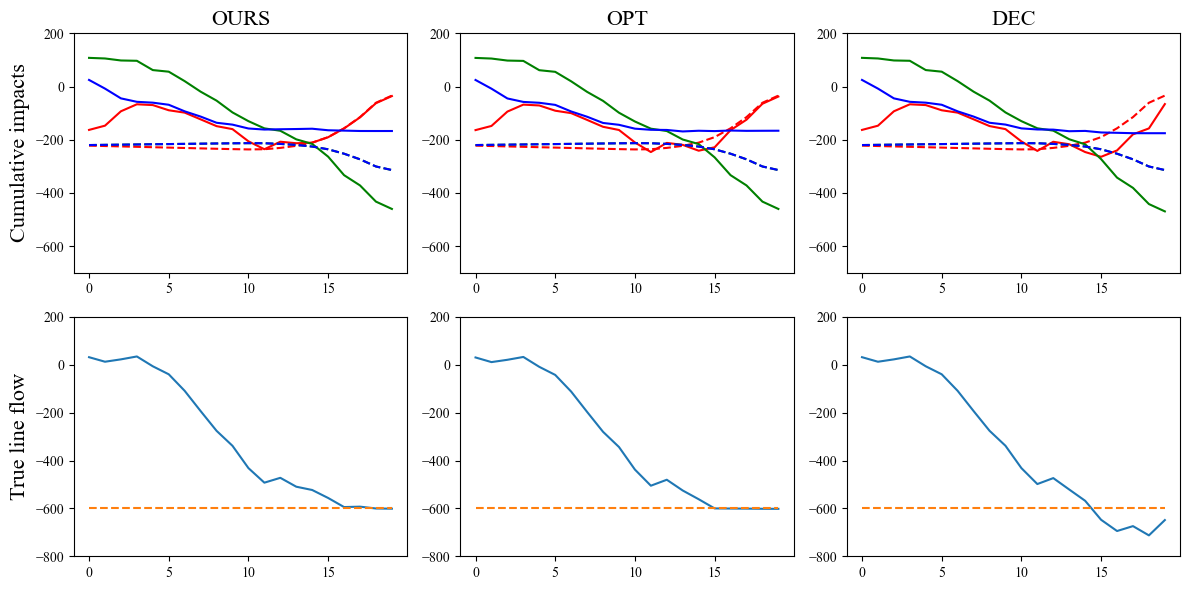

In [41]:
colors = {0: "red", 1: "green", 2: "blue"}
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
fig, axs = plt.subplots(2,3,figsize=(12,6))
colors = {0: "red", 1: "green", 2: "blue"}

for i in range(3):
    # axs[0,0].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,0].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,0].plot(impacts_ours[i], color=colors[i])
axs[0,0].set_title("OURS",fontsize=16)
axs[0,0].set_ylabel("Cumulative impacts",fontsize=16)
axs[0,0].set_ylim([-700,200])
axs[1,0].plot(true_line_flow_ours)
axs[1,0].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,0].set_ylabel("True line flow",fontsize=16)
axs[1,0].set_ylim([-800,200])

for i in range(3):
    # axs[0,1].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,1].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,1].plot(impacts_opt[i], color=colors[i])
axs[0,1].set_title("OPT",fontsize=16)
axs[0,1].set_ylim([-700,200])
axs[1,1].plot(true_line_flow_opt)
axs[1,1].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,1].set_ylim([-800,200])

for i in range(3):
    # axs[0,2].plot(torch.cumsum(line_max_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,2].plot(torch.cumsum(line_min_changes[i,0:T,53],dim=0).detach(), color=colors[i], linestyle="--")
    axs[0,2].plot(impacts_base[i], color=colors[i])
axs[0,2].set_title("DEC",fontsize=16)
axs[0,2].set_ylim([-700,200])
axs[1,2].plot(true_line_flow_base)
axs[1,2].plot(-grid.line_data[line,5] * torch.ones(T),linestyle="--")
axs[1,2].set_ylim([-800,200])

fig.tight_layout()
fig.savefig("figures/easy case.png", dpi=500, bbox_inches='tight')